# Etiquetado del conjunto de datos

**Objetivo:** Producir `etiquetas_ground_truth.parquet`, un archivo con una fila por cada timestamp disponible en la serie horaria de cada estación, con una columna `etiqueta` (0/1) que indica si **3 horas después** de ese momento se registró lluvia fuerte.

**Insumos:**
- `df_horaria.parquet` — serie horaria de intensidad (rolling 60 min) para las 63 estaciones 
- `umbral_operativo_por_estacion.csv` — umbral P95 por estación (salida de notebook 04)

**Lógica de etiquetado:**  
Para cada par `(estación, t)`:  
→ si `intensidad_en(estación, t + 3h) ≥ umbral_estación` → `etiqueta = 1`  
→ si no → `etiqueta = 0`  
→ si no hay dato en `t + 3h` (gap o borde del dataset) → `etiqueta = NaN` (se excluye del entrenamiento)

**Resultado:** `etiquetas_ground_truth.parquet` con columnas `codigoestacion`, `fechaobservacion`, `etiqueta`.


## 1. Configuración

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
from matplotlib.patches import ConnectionPatch
from mpl_toolkits.axes_grid1 import make_axes_locatable


# ── Rutas ────────────────────────────────────────────────────────────────────
RUTA_GT = Path('.')           # carpeta de esta notebook (data_ingestion/ground_truth/)
RUTA_HORARIA   = RUTA_GT / 'df_horaria.parquet'
RUTA_UMBRAL    = RUTA_GT / 'umbral_operativo_por_estacion.csv'
RUTA_SALIDA    = RUTA_GT / 'etiquetas_ground_truth.parquet'

# ── Parámetros ───────────────────────────────────────────────────────────────
HORIZONTE  = pd.Timedelta('3h')   # horizonte de predicción
TOLERANCIA = pd.Timedelta('10min') # margen para buscar t+3h en serie irregular

## 2. Carga de insumos

In [2]:
# ── Umbral por estación ──────────────────────────────────────────────────────
umbral_df = pd.read_csv(RUTA_UMBRAL, dtype={'codigoestacion': str})
umbral = umbral_df.set_index('codigoestacion')['umbral_mm_h']
print(f"Umbrales cargados: {len(umbral)} estaciones")
print(umbral_df[['codigoestacion','umbral_mm_h','origen']].head())

Umbrales cargados: 63 estaciones
  codigoestacion  umbral_mm_h  origen
0     0021201980          7.1  propio
1     0021202180          5.6  propio
2     0021202190          3.2  propio
3     0021202220          8.9  propio
4     0021202230          2.6  propio


In [3]:
# ── Serie horaria ────────────────────────────────────────────────────────────
df_horaria = pd.read_parquet(RUTA_HORARIA)
print(f"Shape: {df_horaria.shape}")
print(f"Columnas: {df_horaria.columns.tolist()}")
print(f"dtypes:")
print(df_horaria.dtypes)
print()
print(df_horaria.head())

Shape: (22774536, 3)
Columnas: ['codigoestacion', 'fechaobservacion', 'intensidad_mm_h']
dtypes:
codigoestacion              object
fechaobservacion    datetime64[ns]
intensidad_mm_h            float64
dtype: object

  codigoestacion    fechaobservacion  intensidad_mm_h
0     2120000101 2024-01-01 09:09:00              0.0
1     2120000101 2024-01-01 09:13:00              0.0
2     2120000101 2024-01-01 09:17:00              0.0
3     2120000101 2024-01-01 09:21:00              0.0
4     2120000101 2024-01-01 09:26:00              0.0


In [4]:
# ── Ajustar si el nombre de la columna de intensidad es distinto ─────────────
COL_INTENSIDAD = 'intensidad_mm_h'

assert COL_INTENSIDAD in df_horaria.columns, (
    f"Columna '{COL_INTENSIDAD}' no encontrada. "
    f"Columnas disponibles: {df_horaria.columns.tolist()}"
)

# Asegurar tipos correctos
df_horaria['codigoestacion'] = df_horaria['codigoestacion'].astype(str)
df_horaria['fechaobservacion'] = pd.to_datetime(df_horaria['fechaobservacion'])

estaciones = df_horaria['codigoestacion'].unique()
print(f"Estaciones en df_horaria: {len(estaciones)}")
print(f"Período: {df_horaria['fechaobservacion'].min()} → {df_horaria['fechaobservacion'].max()}")

Estaciones en df_horaria: 63
Período: 2024-01-01 09:07:00 → 2025-12-31 23:59:00


## 3. Etiquetado

Para cada timestamp `t` de cada estación, se busca el valor de intensidad en `t + 3h`
dentro de una tolerancia de ±5 min (para manejar la irregularidad de los registros sub-horarios).
Si no hay dato en ese rango, la etiqueta queda como `NaN` y se excluye del entrenamiento.


In [5]:
def etiquetar_estacion(grupo, umbral_est, horizonte=HORIZONTE, tolerancia=TOLERANCIA):
    """
    Etiqueta cada timestamp t de una estación:
      - 1 si la intensidad en t+horizonte >= umbral_est
      - 0 si la intensidad en t+horizonte <  umbral_est
      - NaN si no hay dato en t+horizonte dentro de la tolerancia

    Parámetros
    ----------
    grupo : DataFrame con columnas fechaobservacion e intensidad_mm_h (una sola estación)
    umbral_est : float, umbral operativo de lluvia fuerte para esta estación (mm/h)
    """
    serie = (
        grupo
        .set_index('fechaobservacion')[COL_INTENSIDAD]
        .sort_index()
    )

    # Timestamps objetivo: t + 3h
    t_objetivo = serie.index + horizonte

    # Buscar el valor más cercano a cada t_objetivo dentro de la tolerancia
    intensidad_futura = serie.reindex(t_objetivo, method='nearest', tolerance=tolerancia)
    intensidad_futura.index = serie.index   # restaurar índice original

    # Comparar contra umbral
    etiqueta = pd.array(
        np.where(
            intensidad_futura.isna(),
            pd.NA,
            (intensidad_futura >= umbral_est).astype(int)
        ),
        dtype=pd.Int8Dtype()
    )

    return pd.Series(etiqueta, index=serie.index, name='etiqueta')

In [6]:
resultados = []
sin_umbral = []

for codigo, grupo in df_horaria.groupby('codigoestacion'):
    if codigo not in umbral.index:
        sin_umbral.append(codigo)
        continue

    etiq = etiquetar_estacion(grupo, umbral[codigo])

    df_res = pd.DataFrame({
        'codigoestacion':  codigo,
        'fechaobservacion': etiq.index,
        'etiqueta':         etiq.values
    })
    resultados.append(df_res)

if sin_umbral:
    print(f"⚠️  Sin umbral disponible (se omiten): {sin_umbral}")

df_etiquetas = pd.concat(resultados, ignore_index=True)
print(f"Dataset etiquetado: {len(df_etiquetas):,} filas · {df_etiquetas['codigoestacion'].nunique()} estaciones")

Dataset etiquetado: 22,774,536 filas · 63 estaciones


## 4. Resumen del etiquetado

In [7]:
total     = df_etiquetas['etiqueta'].notna().sum()
positivos = (df_etiquetas['etiqueta'] == 1).sum()
negativos = (df_etiquetas['etiqueta'] == 0).sum()
sin_dato  = df_etiquetas['etiqueta'].isna().sum()

print("=" * 50)
print(f"  Total con etiqueta válida : {total:>10,}")
print(f"  Positivos (lluvia fuerte) : {positivos:>10,}  ({100*positivos/total:.2f}%)")
print(f"  Negativos                 : {negativos:>10,}  ({100*negativos/total:.2f}%)")
print(f"  Sin dato en t+3h (NaN)   : {sin_dato:>10,}")
print("=" * 50)

  Total con etiqueta válida : 22,127,940
  Positivos (lluvia fuerte) :     58,778  (0.27%)
  Negativos                 : 22,069,162  (99.73%)
  Sin dato en t+3h (NaN)   :    646,596


In [8]:
# Positivos por estación — para detectar estaciones con muy pocos o muchos eventos
resumen_estacion = (
    df_etiquetas[df_etiquetas['etiqueta'].notna()]
    .groupby('codigoestacion')['etiqueta']
    .agg(
        total='count',
        positivos='sum',
    )
    .assign(pct_positivos=lambda x: 100 * x['positivos'] / x['total'])
    .sort_values('pct_positivos', ascending=False)
)

print(resumen_estacion.describe().round(2))
print()
print("Estaciones con más positivos:")
print(resumen_estacion.head(10).to_string())

           total  positivos  pct_positivos
count       63.0       63.0           63.0
mean   351237.14     932.98           0.26
std    140031.42     565.32           0.11
min      38210.0       40.0           0.07
25%     314406.0      544.5           0.19
50%     422358.0      853.0           0.26
75%     440835.5     1370.5           0.32
max     466978.0     2497.0           0.59

Estaciones con más positivos:
                 total  positivos  pct_positivos
codigoestacion                                  
0021202230      425098       2497       0.587394
0021202190      411427       2416       0.587224
0021205910       54648        265       0.484922
2120000128      428838       1811       0.422304
2120000171      442687       1841       0.415869
2120000127      429871       1756       0.408495
0021205710       55536        219       0.394339
0021206560       54977        205       0.372883
2120000105      432191       1541       0.356555
2120000109      426741       1510       0.3

In [9]:
# Positivos por año y temporada — para verificar que la distribución es razonable
df_etiquetas['anio'] = df_etiquetas['fechaobservacion'].dt.year
df_etiquetas['mes']  = df_etiquetas['fechaobservacion'].dt.month

resumen_anio = (
    df_etiquetas[df_etiquetas['etiqueta'].notna()]
    .groupby('anio')['etiqueta']
    .agg(total='count', positivos='sum')
    .assign(pct=lambda x: 100 * x['positivos'] / x['total'])
)
print(resumen_anio.to_string())

         total  positivos       pct
anio                               
2024   6461761      15959  0.246976
2025  15666179      42819  0.273321


## 5. Guardar

In [10]:
# Eliminar columnas auxiliares antes de guardar
df_salida = df_etiquetas[['codigoestacion', 'fechaobservacion', 'etiqueta']].copy()

df_salida.to_parquet(RUTA_SALIDA, index=False)
print(f"Guardado: {RUTA_SALIDA}")
print(f"Shape final: {df_salida.shape}")

Guardado: etiquetas_ground_truth.parquet
Shape final: (22774536, 3)


## 6. Verificación visual

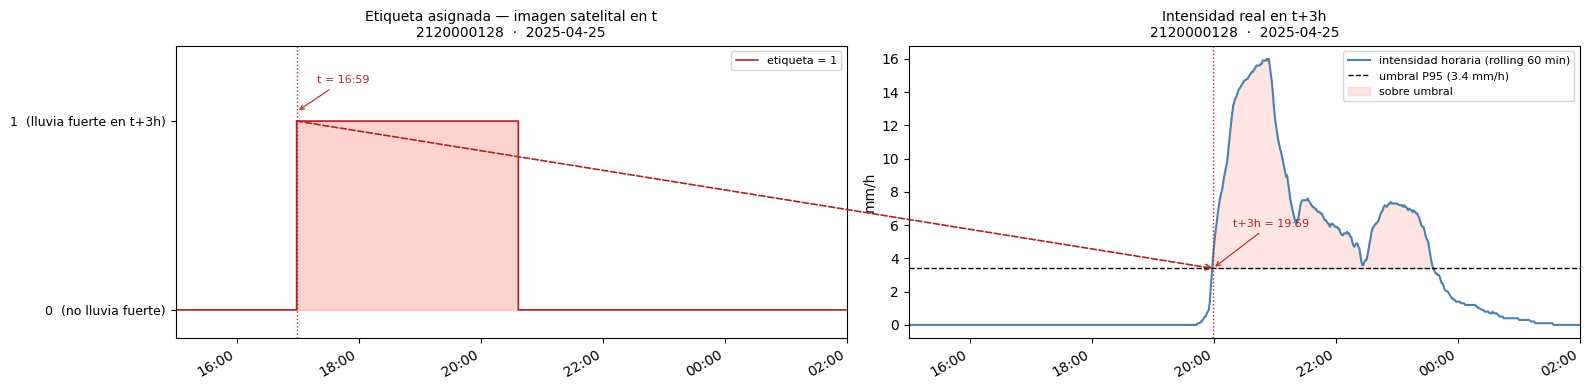

In [32]:
ESTACION  = '2120000128'
FECHA     = '2025-04-25'
t0        = pd.Timestamp(FECHA)

# ── Datos ────────────────────────────────────────────────────────────────────
serie = (
    df_horaria[df_horaria['codigoestacion'] == ESTACION]
    .set_index('fechaobservacion')[COL_INTENSIDAD]
    .sort_index()
)
etiq = (
    df_etiquetas[df_etiquetas['codigoestacion'] == ESTACION]
    .set_index('fechaobservacion')['etiqueta']
    .sort_index()
)
umbral_est = umbral[ESTACION]

# Ventana compartida para ambos paneles: 15:00 → 02:00
t_ini = t0 + pd.Timedelta('15h')
t_fin = t0 + pd.Timedelta('26h')

serie_v = serie.loc[t_ini:t_fin]
etiq_v  = etiq.loc[t_ini:t_fin]

# Primer instante con etiqueta = 1 y su evento correspondiente
t_label_inicio = etiq_v[etiq_v == 1].index[0]
t_evento_inicio = t_label_inicio + pd.Timedelta('3h')

# ── Figura ───────────────────────────────────────────────────────────────────
fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(16, 4), sharey=False)

# ── Panel izquierdo: etiqueta asignada ───────────────────────────────────────
ax2.fill_between(etiq_v.index, 0, etiq_v.fillna(0).astype(int),
                 step='post', alpha=0.35, color='salmon')
ax2.step(etiq_v.index, etiq_v.fillna(0).astype(int),
         color='firebrick', lw=1.2, where='post', label='etiqueta = 1')
ax2.set_ylim(-0.15, 1.4)
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['0  (no lluvia fuerte)', '1  (lluvia fuerte en t+3h)'], fontsize=9)
ax2.set_title(f'Etiqueta asignada — imagen satelital en t\n{ESTACION}  ·  {FECHA}', fontsize=10)
ax2.set_xlim(t_ini, t_fin)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax2.legend(fontsize=8)

# Marca del instante de inicio de etiqueta=1
ax2.axvline(t_label_inicio, color='firebrick', lw=1, ls=':')
ax2.annotate(
    f't = {t_label_inicio.strftime("%H:%M")}',
    xy=(t_label_inicio, 1.05),
    xytext=(t_label_inicio + pd.Timedelta('20min'), 1.2),
    fontsize=8, color='firebrick',
    arrowprops=dict(arrowstyle='->', color='firebrick', lw=0.8)
)

# ── Panel derecho: intensidad real ───────────────────────────────────────────
ax1.plot(serie_v.index, serie_v.values, color='steelblue', lw=1.5,
         label='intensidad horaria (rolling 60 min)')
ax1.axhline(umbral_est, color='black', ls='--', lw=1,
            label=f'umbral P95 ({umbral_est} mm/h)')
ax1.fill_between(serie_v.index, umbral_est, serie_v.values,
                 where=(serie_v.values >= umbral_est),
                 alpha=0.2, color='salmon', label='sobre umbral')
ax1.set_title(f'Intensidad real en t+3h\n{ESTACION}  ·  {FECHA}', fontsize=10)
ax1.set_ylabel('mm/h')
ax1.set_xlim(t_ini, t_fin)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax1.legend(fontsize=8)

# Marca del instante del evento
ax1.axvline(t_evento_inicio, color='firebrick', lw=1, ls=':')
ax1.annotate(
    f't+3h = {t_evento_inicio.strftime("%H:%M")}',
    xy=(t_evento_inicio, umbral_est),
    xytext=(t_evento_inicio + pd.Timedelta('20min'), umbral_est + 2.5),
    fontsize=8, color='firebrick',
    arrowprops=dict(arrowstyle='->', color='firebrick', lw=0.8)
)

# ── Flecha entre paneles ──────────────────────────────────────────────────────
con = ConnectionPatch(
    xyA=(mdates.date2num(t_label_inicio), 1.0),
    coordsA=ax2.transData,
    xyB=(mdates.date2num(t_evento_inicio), umbral_est),
    coordsB=ax1.transData,
    axesA=ax2, axesB=ax1,
    arrowstyle='->', color='firebrick',
    lw=1.2, linestyle='dashed'
)
fig.add_artist(con)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [16]:
# ── Inspección de NaNs ───────────────────────────────────────────────────────

nans = df_etiquetas[df_etiquetas['etiqueta'].isna()].copy()
nans['anio'] = nans['fechaobservacion'].dt.year
nans['mes']  = nans['fechaobservacion'].dt.month

print(f"Total NaN: {len(nans):,}")
print()

# ¿Cuándo ocurren? ¿Al final del dataset o también en el medio?
print("── Por año/mes ─────────────────────────────────────────────────────")
print(nans.groupby(['anio','mes']).size().to_string())
print()

# ¿Están concentrados en pocas estaciones o distribuidos?
print("── Por estación (top 15) ───────────────────────────────────────────")
print(nans.groupby('codigoestacion').size().sort_values(ascending=False).head(15).to_string())
print()

# ¿En qué rango de fechas cae cada estación?
print("── Primer y último NaN por estación ───────────────────────────────")
resumen_nan = nans.groupby('codigoestacion')['fechaobservacion'].agg(['min','max'])
print(resumen_nan.to_string())

Total NaN: 646,596

── Por año/mes ─────────────────────────────────────────────────────
anio  mes
2024  1      33503
      2      22337
      3      45400
      4      14640
      5      23862
      6       4915
      7      18638
      8      20912
      9      13968
      10     29052
      11     27130
      12     26707
2025  1      27410
      2      14266
      3      35982
      4      27053
      5      45831
      6      19163
      7      16944
      8      19549
      9      54565
      10     43541
      11     34346
      12     26882

── Por estación (top 15) ───────────────────────────────────────────
codigoestacion
0021202190    16448
0021206890    15672
2120000172    15472
2120000139    15254
2120000118    14998
0021202250    14880
2120000120    13936
2120000169    13633
2120000134    13445
2120000133    13353
0021202220    13151
2120700154    13058
2120000173    12931
2120000131    12810
2120000126    12546

── Primer y último NaN por estación ───────────────────────

In [15]:
# Para cada estación: primer y último registro real en df_horaria
bordes = (
    df_horaria.groupby('codigoestacion')['fechaobservacion']
    .agg(inicio_estacion='min', fin_estacion='max')
)

# Unir con los NaNs
nans_con_bordes = (
    nans[['codigoestacion','fechaobservacion']]
    .join(bordes, on='codigoestacion')
)

# Clasificar cada NaN
nans_con_bordes['tipo'] = 'interior'  # default: gap en el medio

# Borde de inicio: NaN dentro de las primeras 3h de la estación
mask_inicio = (
    nans_con_bordes['fechaobservacion'] <= 
    nans_con_bordes['inicio_estacion'] + HORIZONTE
)
# Borde de fin: NaN dentro de las últimas 3h de la estación
mask_fin = (
    nans_con_bordes['fechaobservacion'] >= 
    nans_con_bordes['fin_estacion'] - HORIZONTE
)

nans_con_bordes.loc[mask_inicio, 'tipo'] = 'borde_inicio'
nans_con_bordes.loc[mask_fin,    'tipo'] = 'borde_fin'

# Resumen
print("── Clasificación de NaNs ───────────────────────────────────────────")
print(nans_con_bordes['tipo'].value_counts().to_string())
print()

# ¿Qué estaciones tienen NaNs interiores?
interiores = nans_con_bordes[nans_con_bordes['tipo'] == 'interior']
print(f"── Estaciones con NaNs interiores: {interiores['codigoestacion'].nunique()} ──")
print(
    interiores.groupby('codigoestacion')
    .size()
    .sort_values(ascending=False)
    .to_string()
)

── Clasificación de NaNs ───────────────────────────────────────────
tipo
interior        638094
borde_fin         8452
borde_inicio        50

── Estaciones con NaNs interiores: 63 ──
codigoestacion
0021202190    16278
0021206890    15502
2120000172    15301
2120000139    15158
2120000118    14828
0021202250    14710
2120000120    13766
2120000169    13463
2120000134    13275
2120000133    13183
0021202220    12981
2120700154    12888
2120000173    12757
2120000131    12640
2120000126    12376
0021206810    12208
2120000119    12060
2120000174    11913
2120000170    11815
2120000129    11805
2120000128    11786
2120000105    11636
2120000130    11614
2120000127    11584
0021208480    11579
2120000137    11524
2120000175    11498
2120000135    11463
2120000125    11455
2120500201    11430
0021202230    11428
2120000132    11344
2120000140    11314
2120000124    11309
2120000171    11291
0021202240    11260
2120000109    11241
2120000123    11224
2120000121    11193
2120000122    11058


In [17]:
# ── Cargar datos ─────────────────────────────────────────────────────────────
RUTA_QC = Path('../../data_ingestion/ground_truth/resumen_qc_66_estaciones_original.csv')

qc = pd.read_csv(RUTA_QC, dtype={'codigo': str})
qc['codigo'] = qc['codigo'].str.strip()

# Unir con umbrales operativos
umbral_df['codigoestacion'] = umbral_df['codigoestacion'].str.strip()
mapa_df = qc.merge(
    umbral_df[['codigoestacion', 'umbral_mm_h']],
    left_on='codigo',
    right_on='codigoestacion',
    how='inner'
)

print(f"Estaciones en el mapa: {len(mapa_df)}")
print(f"Rango umbral: {mapa_df['umbral_mm_h'].min():.1f} – {mapa_df['umbral_mm_h'].max():.1f} mm/h")

Estaciones en el mapa: 63
Rango umbral: 2.6 – 16.2 mm/h


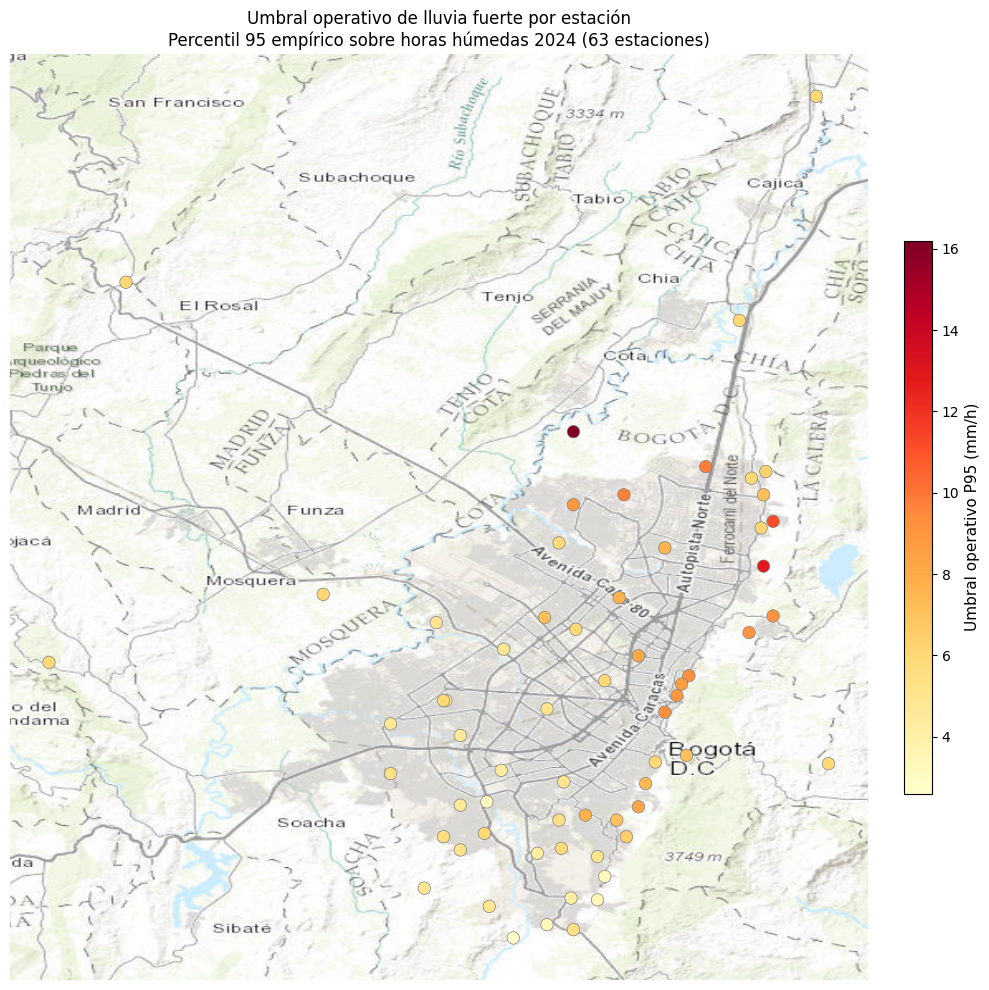

In [ ]:
import contextily as ctx
import geopandas as gpd
from shapely.geometry import Point

fig, ax = plt.subplots(figsize=(10, 10))

# ── Convertir a GeoDataFrame en WGS84 y reproyectar a Web Mercator ───────────
gdf = gpd.GeoDataFrame(
    mapa_df,
    geometry=[Point(lon, lat) for lon, lat in zip(mapa_df['longitud'], mapa_df['latitud'])],
    crs='EPSG:4326'
).to_crs(epsg=3857)


cmap = plt.cm.YlOrRd
norm = mcolors.Normalize(
    vmin=mapa_df['umbral_mm_h'].min(),
    vmax=mapa_df['umbral_mm_h'].max()
)

# Usar scatter sobre coordenadas proyectadas (no gdf.plot)
sc = ax.scatter(
    gdf.geometry.x,
    gdf.geometry.y,
    c=gdf['umbral_mm_h'],
    cmap=cmap,
    norm=norm,
    s=80,
    edgecolors='grey',
    linewidths=0.5,
    zorder=5
)

# Mapa base sin API key
ctx.add_basemap(
    ax,
    crs=gdf.crs,
    source='https://server.arcgisonline.com/ArcGIS/rest/services/World_Topo_Map/MapServer/tile/{z}/{y}/{x}',
    zoom=11
)

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cb = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
cb.set_label('Umbral operativo P95 (mm/h)', fontsize=11)

ax.set_axis_off()
ax.set_title(
    'Umbral operativo de lluvia fuerte por estación\n'
    'Percentil 95 empírico sobre horas húmedas 2024 (63 estaciones)',
    fontsize=12
)

plt.tight_layout()
plt.show()